# WISDM Fenstergrössen-Experiment

**Fragestellung:** Ab welcher Reaktionszeit wird die Aktivitaetserkennung unzuverlaessig?

Wir untersuchen, wie sich verschiedene Klassifikatoren (k-NN, SVM, Random Forest, MLP) verhalten, wenn das Smartphone nur wenig Zeit hat, eine Aktivitaet zu erkennen.


https://github.com/Knyllahsyhn/classifier

## 1. Setup

In [46]:
from pathlib import PurePosixPath
from timeit import default_repeat

# Dependencies (in Colab bereits vorinstalliert)
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import urllib.request
import tarfile
warnings.filterwarnings('ignore')

print("Setup abgeschlossen!")

Setup abgeschlossen!


## 2. Konfiguration

In [47]:

# KONFIGURATION


# Output-Verzeichnis fuer Plots und Ergebnisse
OUTPUT_DIR = "output"
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fenstergrössen zum Testen (bei ~20 Hz Samplerate)
WINDOW_SIZES = [50, 75, 100, 150, 200, 300, 400]
# Entspricht ca.: 2.5s, 3.75s, 5s, 7.5s, 10s, 15s, 20s

STEP_RATIO = 0.5  # 50% Overlap

# Datensatz-Pfade
TRAIN_DATA_PATH = "data/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt"  # AR fuer Training
TEST_DATA_PATH = "data/WISDM_at_v2.0/WISDM_at_v2.0_raw.txt"  # AT fuer Test

# Test auf seperatem Datensatz? (Falls False, wird Train/Test-Split auf AR gemacht)
USE_AT_FOR_TESTING = True  # Auf True setzen wenn AT-Datensatz vorhanden

SAMPLE_RATE_HZ = 20  # Ungefaehre Samplerate des Datensatzes

# Reaktionszeiten anzeigen
print("Fenstergrössen und entsprechende Reaktionszeiten:")
for w in WINDOW_SIZES:
    print(f"  {w:3d} Samples = {w/SAMPLE_RATE_HZ:5.2f} Sekunden")

Fenstergrössen und entsprechende Reaktionszeiten:
   50 Samples =  2.50 Sekunden
   75 Samples =  3.75 Sekunden
  100 Samples =  5.00 Sekunden
  150 Samples =  7.50 Sekunden
  200 Samples = 10.00 Sekunden
  300 Samples = 15.00 Sekunden
  400 Samples = 20.00 Sekunden


## 3. Datensatz laden

Prueft automatisch ob die Daten lokal vorhanden sind. Falls nicht, werden sie heruntergeladen.

In [48]:


# PFADE KONFIGURATION


# Baedir fuer Datasets
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

# Datensatz-Pfade
TRAIN_DATA_PATH = f"{DATA_DIR}/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt"
TEST_DATA_PATH = f"{DATA_DIR}/WISDM_at_v2.0/WISDM_at_v2.0_raw.txt"

# Download-URLs
WISDM_AR_URL = "https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_ar_latest.tar.gz"
WISDM_AT_URL = "https://www.cis.fordham.edu/wisdm/includes/datasets/latest/WISDM_at_latest.tar.gz"


# Sets sind unterschiedlich gepackt, directory traversal nutzen
def deepest_dir(members):
    dirs = set()
    for m in members:
        p = PurePosixPath(m.name)
        if m.isdir():
            dirs.add(p)
        elif p.parent != PurePosixPath("."):
            dirs.add(p.parent)
        return max(dirs, key =lambda p: len(p.parts))


def download_and_extract(url, target_dir, name):
    """Laedt Datensatz herunter und entpackt ihn."""
    archive_path = os.path.join(target_dir, f"{name}.tar.gz")
    
    print(f"Lade {name} herunter...")
    urllib.request.urlretrieve(url, archive_path)
    
    print(f"Entpacke {name}...")
    with tarfile.open(archive_path, 'r:gz') as tar:
        members = tar.getmembers()
        deepest = deepest_dir(members)
        selected=[]
        parent = deepest.parent
        for m in members:
            p = PurePosixPath(m.name)
            if p == deepest or deepest in p.parents:
                m.name = str(p.relative_to(parent))
                selected.append(m)
        tar.extractall(path=target_dir, members= selected)
    
    # Archiv löschen
    os.remove(archive_path)
    !ls
    print(f"{name} erfolgreich heruntergeladen!")

# WISDM AR (Trainingsdaten)
if os.path.exists(TRAIN_DATA_PATH):
    print(f"Trainingsdaten gefunden: {TRAIN_DATA_PATH}")
else:
    print(f"Trainingsdaten nicht gefunden")
    download_and_extract(WISDM_AR_URL, DATA_DIR, "WISDM_ar")

# WISDM AT (Testdaten)
if USE_AT_FOR_TESTING:
    if os.path.exists(TEST_DATA_PATH):
        print(f"Testdaten gefunden: {TEST_DATA_PATH}")
    else:
        print(f"Testdaten nicht gefunden")
        download_and_extract(WISDM_AT_URL, DATA_DIR, "WISDM_at")

Trainingsdaten gefunden: ./data/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt
Testdaten gefunden: ./data/WISDM_at_v2.0/WISDM_at_v2.0_raw.txt


## 4. Hilfsfunktionen

In [49]:
def load_wisdm_data(filepath):
    # Laedt die WISDM-Rohdaten in einen Dataframe
    data = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line:
                continue
            parts = line.split(',')
            if len(parts) == 6:
                try:
                    user = int(parts[0])
                    activity = parts[1].strip()
                    timestamp = int(parts[2])
                    x = float(parts[3])
                    y = float(parts[4])
                    z = float(parts[5].rstrip(';'))
                    data.append([user, activity, timestamp, x, y, z])
                except (ValueError, IndexError):
                    continue
    return pd.DataFrame(data, columns=['user', 'activity', 'timestamp', 'x', 'y', 'z'])


def extract_features_vectorized(windows):
   # Vektorisierte Extraktion edr Features , da Zeitaufwand klassisch per Loop zu hoch.
    feature_list = []
    
    for axis in range(3):
        data = windows[:, :, axis]
        
        feature_list.append(np.mean(data, axis=1))
        feature_list.append(np.std(data, axis=1))
        feature_list.append(np.min(data, axis=1))
        feature_list.append(np.max(data, axis=1))
        feature_list.append(np.max(data, axis=1) - np.min(data, axis=1))
        feature_list.append(np.median(data, axis=1))
        feature_list.append(stats.skew(data, axis=1))
        feature_list.append(stats.kurtosis(data, axis=1))
        feature_list.append(np.sqrt(np.mean(data**2, axis=1)))
        feature_list.append(np.sum(np.abs(np.diff(data, axis=1)), axis=1))
    
    magnitude = np.sqrt(windows[:,:,0]**2 + windows[:,:,1]**2 + windows[:,:,2]**2)
    feature_list.append(np.mean(magnitude, axis=1))
    feature_list.append(np.std(magnitude, axis=1))
    feature_list.append(np.max(magnitude, axis=1) - np.min(magnitude, axis=1))
    
    return np.array(feature_list).T


def create_dataset(df, window_size, step_size):
    # Erstellt Feature-Datensatz aus Rohdaten mit gegebener Fenstergrösse
    X_list = []
    y_list = []
    
    for (user, activity), group in df.groupby(['user', 'activity']):
        group = group.sort_values('timestamp').reset_index(drop=True)
        data = group[['x', 'y', 'z']].values
        n_samples = len(data)
        n_windows = (n_samples - window_size) // step_size + 1
        
        if n_windows <= 0:
            continue
        
        indices = np.arange(n_windows)[:, None] * step_size + np.arange(window_size)
        windows = data[indices]
        features = extract_features_vectorized(windows)
        
        X_list.append(features)
        y_list.extend([activity] * n_windows)
    
    X = np.vstack(X_list)
    y = np.array(y_list)
    
    mask = ~(np.isnan(X).any(axis=1) | np.isinf(X).any(axis=1))
    return X[mask], y[mask]


def get_classifiers():
    # Gibt Dictionary mit allen Klassifikatoren zurueck
    return {
        "k-NN": KNeighborsClassifier(n_neighbors=5),
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale'),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True)
    }


def get_feature_names():
    # Gibt Liste der Feature-Namen zurueck
    feature_names = []
    for axis in ['x', 'y', 'z']:
        for feat in ['mean', 'std', 'min', 'max', 'range', 'median', 'skew', 'kurtosis', 'rms', 'abs_diff']:
            feature_names.append(f"{axis}_{feat}")
    feature_names.extend(['mag_mean', 'mag_std', 'mag_range'])
    return feature_names


# =============================================================================
# Zentrale Funktionen fuer Experimente
# =============================================================================

def prepare_data(df_train, df_test, window_size, step_ratio, use_at_for_testing=True, fixed_sample_count=None):
    """
    Bereitet Train/Test-Daten vor.fuer die Experimente
    
    Args:
        df_train: DataFrame mit Trainingsdaten (AR)
        df_test: DataFrame mit Testdaten (AT), kann None sein
        window_size: Fenstergrösse in Samples
        step_ratio: Overlap-Ratio (0.5 = 50% Overlap)
        use_at_for_testing: Wenn True, wird df_test fuer Test verwendet
        fixed_sample_count: Wenn gesetzt, werden Trainingssamples auf diese Anzahl reduziert
    
    Returns:
        X_train, X_test, y_train, y_test, label_encoder
    """
    step_size = int(window_size * step_ratio)
    
    # Feature-Extraktion Training
    X_train_full, y_train_full = create_dataset(df_train, window_size, step_size)
    
    # Label Encoder vorbereiten
    le = LabelEncoder()
    
    if use_at_for_testing and df_test is not None:
        # Test auf separatem Datensatz (AT)
        X_test, y_test_raw = create_dataset(df_test, window_size, step_size)
        le.fit(np.concatenate([y_train_full, y_test_raw]))
        y_test = le.transform(y_test_raw)
        y_train_full_enc = le.transform(y_train_full)
    else:
        # Train/Test Split auf AR
        le.fit(y_train_full)
        y_train_full_enc = le.transform(y_train_full)
        X_train_full, X_test, y_train_full_enc, y_test = train_test_split(
            X_train_full, y_train_full_enc, test_size=0.3, random_state=42, stratify=y_train_full_enc  #random state als seed fuer reproduzierbarkeit
        )
    
    #  Trainingssamples reduzieren: optional, aber habs mal drin gelassen
    if fixed_sample_count is not None and len(X_train_full) > fixed_sample_count:
        keep_ratio = fixed_sample_count / len(X_train_full)
        X_train, _, y_train, _ = train_test_split(
            X_train_full, y_train_full_enc, train_size=keep_ratio, random_state=42, stratify=y_train_full_enc
        )
    else:
        X_train, y_train = X_train_full, y_train_full_enc
    
    return X_train, X_test, y_train, y_test, le


def train_and_evaluate(X_train, X_test, y_train, y_test, window_size, sample_rate_hz, classifiers=None):
    """
    Trainiert alle Klassifikatoren und wertet sie aus.
    
    Args:
        X_train, X_test, y_train, y_test: Vorbereitete Daten
        window_size: Fenstergrösse (fuer Metadaten)
        sample_rate_hz: Samplerate (fuer Reaktionszeit-Berechnung)
        classifiers: Optional, Dictionary mit Klassifikatoren (default: get_classifiers())
    
    Returns:
        Liste von Result-Dicts
    """
    if classifiers is None:
        classifiers = get_classifiers()
    
    # Skalierung
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    reaction_time = window_size / sample_rate_hz
    results = []
    
    for name, clf in classifiers.items():
        start = time.time()
        
        # Random Forest braucht keine Skalierung
        if name == "Random Forest":
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
        else:
            clf.fit(X_train_scaled, y_train)
            y_pred = clf.predict(X_test_scaled)
        
        elapsed = time.time() - start
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')
        
        results.append({
            'window_size': window_size,
            'reaction_time_s': reaction_time,
            'classifier': name,
            'accuracy': acc,
            'f1_score': f1,
            'train_time': elapsed,
            'n_train': len(X_train),
            'n_test': len(X_test)
        })
        
        print(f"  {name:15s}: {100*acc:5.1f}% (F1: {f1:.3f})")
    
    return results


def run_experiment(df_train, df_test, window_sizes, step_ratio, sample_rate_hz, 
                   use_at_for_testing=True, fixed_sample_count=None, experiment_name=""):
    """
    Fuehrt ein komplettes Experiment ueber alle Fenstergrössen durch.
    
    Args:
        df_train, df_test: DataFrames mit Roh-Daten
        window_sizes: Liste der zu testenden Fenstergrössen
        step_ratio: Overlap-Ratio
        sample_rate_hz: Samplerate
        use_at_for_testing: Test auf AT-Datensatz ja/nein
        fixed_sample_count: Fixe Trainingssamples (None = alle verwenden)
        experiment_name: Name fuer Ausgabe
    
    Returns:
        DataFrame mit allen Ergebnissen
    """
    print("=" * 70)
    print(f"EXPERIMENT{': ' + experiment_name if experiment_name else ''}")
    print("=" * 70)
    
    if fixed_sample_count:
        print(f"Trainingssamples: fix auf {fixed_sample_count:,}")
    else:
        print("Trainingssamples: variabel (alle verfuegbaren)")
    print(f"Test auf: {'AT-Datensatz' if use_at_for_testing else 'AR-Datensatz (Split)'}")
    print(f"Fenstergrössen: {window_sizes}")
    
    all_results = []
    
    for window_size in window_sizes:
        reaction_time = window_size / sample_rate_hz
        
        print(f"\n{'='*50}")
        print(f"Fenstergrösse: {window_size} ({reaction_time:.1f}s Reaktionszeit)")
        print(f"{'='*50}")
        
        # Daten vorbereiten
        X_train, X_test, y_train, y_test, le = prepare_data(
            df_train, df_test, window_size, step_ratio,
            use_at_for_testing=use_at_for_testing,
            fixed_sample_count=fixed_sample_count
        )
        
        print(f"Trainingssamples: {len(X_train):,}")
        print(f"Testsamples: {len(X_test):,}")
        print("\nErgebnisse:")
        
        # Trainieren und evaluieren
        results = train_and_evaluate(X_train, X_test, y_train, y_test, window_size, sample_rate_hz)
        all_results.extend(results)
    
    print("\n" + "=" * 70)
    print("Experiment abgeschlossen!")
    print("=" * 70)
    
    return pd.DataFrame(all_results)


print("Hilfsfunktionen geladen!")

Hilfsfunktionen geladen!


In [50]:
# Visualisierungs-Hilfsfunktionen fuer einheitliche Plots

# Einheitliche Farben fuer alle Plots
CLASSIFIER_COLORS = {
    'k-NN': '#1f77b4',
    'SVM': '#ff7f0e', 
    'Random Forest': '#2ca02c',
    'MLP': '#d62728'
}
CLASSIFIER_ORDER = ['k-NN', 'SVM', 'Random Forest', 'MLP']


def plot_accuracy_curves(results_df, title, filename, ylim=(0.3, 0.7)):
    # Plottet Accuracy vs. Reaktionszeit fuer alle Klassifikatoren
    plt.figure(figsize=(10, 6))
    
    for clf in CLASSIFIER_ORDER:
        data = results_df[results_df['classifier'] == clf]
        plt.plot(data['reaction_time_s'], data['accuracy'], 
                 marker='o', label=clf, linewidth=2, markersize=8, 
                 color=CLASSIFIER_COLORS[clf])
    
    plt.xlabel('Reaktionszeit (Sekunden)', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.ylim(ylim)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_metric_curves(results_df, metric, title, filename, ylim=(0.3, 0.7)):
    # Plottet beliebige Metrik vs. Reaktionszeit fuer alle Klassifikatoren.
    plt.figure(figsize=(10, 6))
    
    for clf in CLASSIFIER_ORDER:
        data = results_df[results_df['classifier'] == clf]
        plt.plot(data['reaction_time_s'], data[metric], 
                 marker='o', label=clf, linewidth=2, markersize=8,
                 color=CLASSIFIER_COLORS[clf])
    
    plt.xlabel('Reaktionszeit (Sekunden)', fontsize=12)
    plt.ylabel(metric.replace('_', ' ').title(), fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    if ylim:
        plt.ylim(ylim)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_heatmap(results_df, title, filename, vmin=0.3, vmax=0.7):
    # Plottet Accuracy-Heatmap
    plt.figure(figsize=(10, 6))
    
    pivot = results_df.pivot(index='classifier', columns='reaction_time_s', values='accuracy')
    pivot = pivot.reindex(CLASSIFIER_ORDER)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=vmin, vmax=vmax)
    
    plt.xlabel('Reaktionszeit (Sekunden)', fontsize=12)
    plt.ylabel('Klassifikator', fontsize=12)
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_comparison_bars(results_a, results_b, title, filename, ylim=(0.3, 0.8)):
    # Plottet Balkendiagramm A vs B fuer alle Klassifikatoren
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    window_sizes = sorted(results_a['window_size'].unique())
    x = np.arange(len(window_sizes))
    width = 0.35
    
    for idx, clf in enumerate(CLASSIFIER_ORDER):
        ax = axes[idx]
        
        data_a = results_a[results_a['classifier'] == clf].sort_values('window_size')
        data_b = results_b[results_b['classifier'] == clf].sort_values('window_size')
        
        ax.bar(x - width/2, data_a['accuracy'].values, width, label='Exp. A (variable)', color='#3498db')
        ax.bar(x + width/2, data_b['accuracy'].values, width, label='Exp. B (konstant)', color='#e74c3c')
        
        ax.set_xlabel('Fenstergrösse')
        ax.set_ylabel('Accuracy')
        ax.set_title(clf)
        ax.set_xticks(x)
        ax.set_xticklabels(window_sizes)
        ax.legend(loc='lower right')
        ax.set_ylim(ylim)
        ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_difference(results_a, results_b, title, filename):
    #Plottet Differenz A - B fuer alle Klassifikatoren.
    plt.figure(figsize=(10, 6))
    
    for clf in CLASSIFIER_ORDER:
        data_a = results_a[results_a['classifier'] == clf].sort_values('window_size')
        data_b = results_b[results_b['classifier'] == clf].sort_values('window_size')
        
        diff = data_a['accuracy'].values - data_b['accuracy'].values
        reaction_times = data_a['reaction_time_s'].values
        
        plt.plot(reaction_times, diff * 100, marker='o', label=clf,
                 linewidth=2, markersize=8, color=CLASSIFIER_COLORS[clf])
    
    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Reaktionszeit (Sekunden)', fontsize=12)
    plt.ylabel('Accuracy-Differenz (Prozentpunkte)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, title, filename, cmap='Blues', normalize=False):
    """Plottet Confusion Matrix."""
    plt.figure(figsize=(8, 6))
    
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2f'
    else:
        fmt = 'd'
    
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Vorhergesagt')
    plt.ylabel('Tatsaechlich')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def plot_side_by_side(results_a, results_b, metric, titles, filename, ylim=None):
    #Plottet zwei Experimente nebeneinander.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, results, title in zip(axes, [results_a, results_b], titles):
        for clf in CLASSIFIER_ORDER:
            data = results[results['classifier'] == clf]
            ax.plot(data['reaction_time_s'], data[metric], 
                    marker='o', label=clf, linewidth=2, markersize=8,
                    color=CLASSIFIER_COLORS[clf])
        
        ax.set_xlabel('Reaktionszeit (Sekunden)', fontsize=12)
        ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        if ylim:
            ax.set_ylim(ylim)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{filename}', dpi=150)
    plt.show()


def print_summary_stats(results_df, experiment_name):
    # zusammenfassende Statistiken
    print(f"\n--- {experiment_name} ---")
    best_idx = results_df['accuracy'].idxmax()
    worst_idx = results_df['accuracy'].idxmin()
    
    print(f"Beste: {results_df.loc[best_idx, 'classifier']} "
          f"bei {results_df.loc[best_idx, 'reaction_time_s']}s "
          f"({100*results_df.loc[best_idx, 'accuracy']:.2f}%)")
    print(f"Schlechteste: {results_df.loc[worst_idx, 'classifier']} "
          f"bei {results_df.loc[worst_idx, 'reaction_time_s']}s "
          f"({100*results_df.loc[worst_idx, 'accuracy']:.2f}%)")
    print(f"Durchschnitt: {100*results_df['accuracy'].mean():.2f}%")


print("Visualisierungs-Hilfsfunktionen geladen!")

Visualisierungs-Hilfsfunktionen geladen!


## 5. Daten laden und erkunden

In [51]:
# Trainingsdaten laden
print("Lade Trainingsdaten (WISDM AR)...")
df_train = load_wisdm_data(TRAIN_DATA_PATH)
print(f"Geladene Datenpunkte: {len(df_train):,}")

# Optional: AT-Datensatz laden
if USE_AT_FOR_TESTING:
    print("\nLade Testdaten (WISDM AT)...")
    df_test = load_wisdm_data(TEST_DATA_PATH)
    print(f"Geladene Datenpunkte: {len(df_test):,}")

Geladene Datenpunkte: 2,980,765


In [52]:
# Datensatz erkunden
print("Aktivitaeten im Datensatz:")
print(df_train['activity'].value_counts())

print(f"\nAnzahl Probanden: {df_train['user'].nunique()}")

activity
Walking       418393
Jogging       336445
Upstairs      122869
Downstairs    100425
Sitting        59939
Standing       48394
Name: count, dtype: int64

Anzahl Probanden: 36


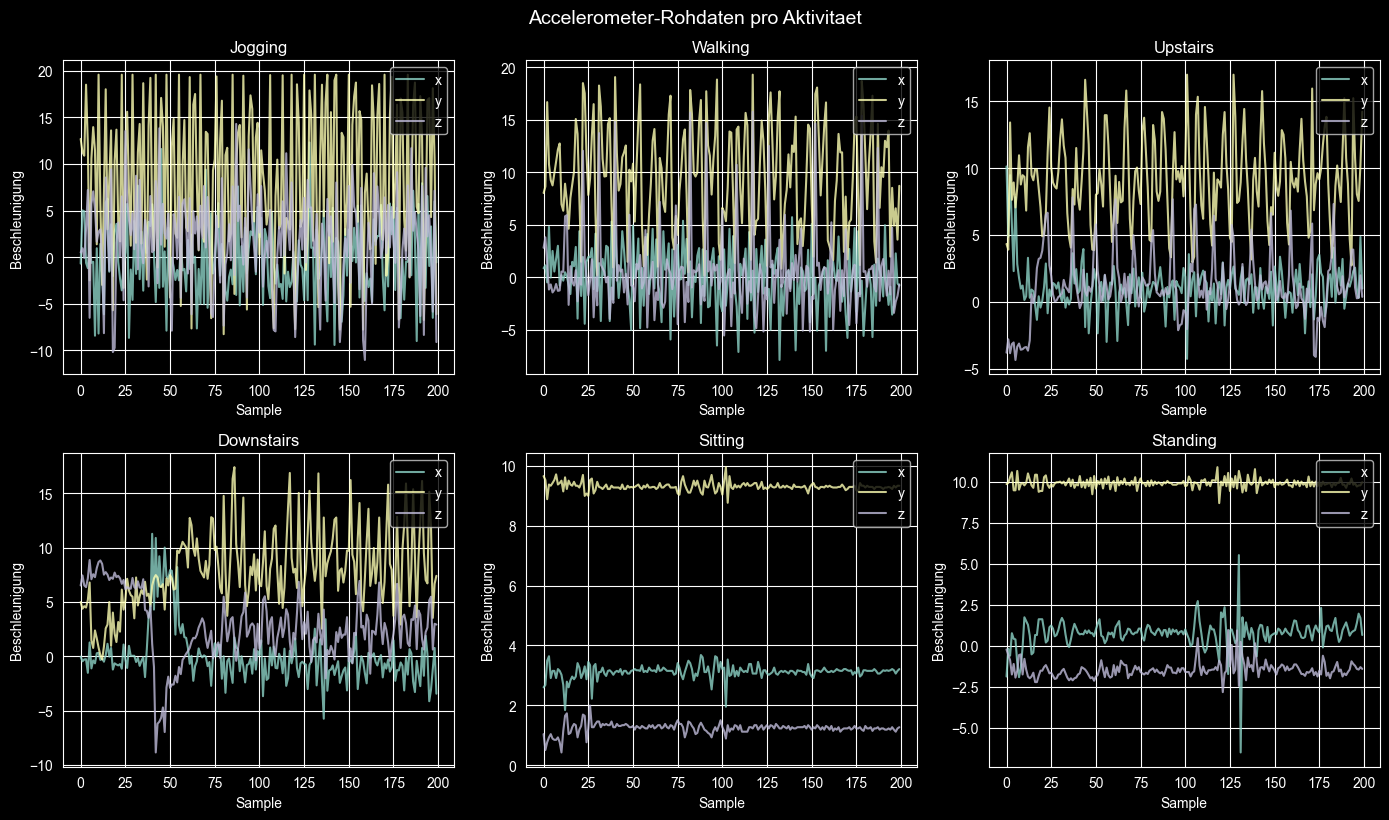

In [53]:
# Visualisierung: Beispiel-Rohdaten
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

activities = df_train['activity'].unique()
for idx, activity in enumerate(activities[:6]):
    ax = axes[idx // 3, idx % 3]
    sample = df_train[df_train['activity'] == activity].head(200)
    ax.plot(sample['x'].values, label='x', alpha=0.8)
    ax.plot(sample['y'].values, label='y', alpha=0.8)
    ax.plot(sample['z'].values, label='z', alpha=0.8)
    ax.set_title(activity)
    ax.legend(loc='upper right')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Beschleunigung')

plt.tight_layout()
plt.suptitle('Accelerometer-Rohdaten pro Aktivitaet', y=1.02, fontsize=14)
plt.show()

## 6. Experiment: Fenstergrössen-Vergleich

In [54]:
# Experiment A: Variable Trainingssetgrösse
results_df = run_experiment(
    df_train=df_train,
    df_test=df_test if USE_AT_FOR_TESTING else None,
    window_sizes=WINDOW_SIZES,
    step_ratio=STEP_RATIO,
    sample_rate_hz=SAMPLE_RATE_HZ,
    use_at_for_testing=USE_AT_FOR_TESTING,
    fixed_sample_count=None,  # Alle Samples verwenden
    experiment_name="A - Variable Trainingssamples"
)

KeyboardInterrupt: 

## 7. Experiment B: Konstante Sample-Anzahl

Im vorherigen Experiment hatten kleinere Fenster automatisch mehr Trainingssamples. Jetzt kontrollieren wir dafuer: **Alle Fenstergrössen bekommen die gleiche Anzahl Samples.**

So sehen wir isoliert, wie sich die Fenstergrösse (= Informationsgehalt pro Sample) auswirkt – unabhaengig von der Trainingssetgrösse.

In [ ]:
# Bestimme Referenz-Sampleanzahl (grösste Fenstergrösse)
max_window = max(WINDOW_SIZES)
step_size_max = int(max_window * STEP_RATIO)
X_ref, _ = create_dataset(df_train, max_window, step_size_max)
FIXED_SAMPLE_COUNT = len(X_ref)

print(f"Referenz: Fenstergrösse {max_window} erzeugt {FIXED_SAMPLE_COUNT:,} Samples")
print(f"Alle Fenstergrössen werden auf diese Anzahl reduziert.\n")

# Experiment B: Konstante Trainingssetgrösse
results_fixed_df = run_experiment(
    df_train=df_train,
    df_test=df_test if USE_AT_FOR_TESTING else None,
    window_sizes=WINDOW_SIZES,
    step_ratio=STEP_RATIO,
    sample_rate_hz=SAMPLE_RATE_HZ,
    use_at_for_testing=USE_AT_FOR_TESTING,
    fixed_sample_count=FIXED_SAMPLE_COUNT,
    experiment_name="B - Konstante Trainingssamples"
)

In [ ]:
# Zusammenfassung Experiment B
print("ZUSAMMENFASSUNG EXPERIMENT B: Konstante Trainingssamples\n")
pivot_b = results_fixed_df.pivot(index='window_size', columns='classifier', values='accuracy')
pivot_b['Reaktionszeit (s)'] = pivot_b.index / SAMPLE_RATE_HZ
pivot_b = pivot_b[['Reaktionszeit (s)'] + CLASSIFIER_ORDER]
print(pivot_b.round(4).to_string())

print_summary_stats(results_fixed_df, "Experiment B")

## 8a. Ergebnisse Experiment A

In [ ]:
# Zusammenfassung Experiment A
print("ZUSAMMENFASSUNG EXPERIMENT A: Variable Trainingssamples\n")
pivot = results_df.pivot(index='window_size', columns='classifier', values='accuracy')
pivot['Reaktionszeit (s)'] = pivot.index / SAMPLE_RATE_HZ
pivot = pivot[['Reaktionszeit (s)'] + CLASSIFIER_ORDER]
print(pivot.round(4).to_string())

print_summary_stats(results_df, "Experiment A")

In [ ]:
# Heatmap Experiment A
plot_heatmap(results_df,
    'Experiment A: Accuracy Heatmap',
    'exp_a_heatmap.png')

In [ ]:
# Accuracy-Kurve Experiment A
plot_accuracy_curves(results_df,
    'Experiment A: Klassifikationsgenauigkeit vs. Reaktionszeit',
    'exp_a_accuracy.png')

## 8b. Visualisierungen Experiment B

In [ ]:
# Heatmap Experiment B
plot_heatmap(results_fixed_df,
    'Experiment B: Accuracy Heatmap (konstante Trainingssamples)',
    'exp_b_heatmap.png')

In [ ]:
# Accuracy-Kurve Experiment B
plot_accuracy_curves(results_fixed_df,
    'Experiment B: Klassifikationsgenauigkeit vs. Reaktionszeit',
    'exp_b_accuracy.png')

## 8c. Direkter Vergleich: Experiment A vs. B

In [ ]:
# Differenz-Plot A vs B
plot_difference(results_df, results_fixed_df,
    'Effekt der Trainingssetgrösse: Accuracy(A) - Accuracy(B)',
    'accuracy_difference.png')

print("Positive Werte = mehr Trainingsdaten helfen")
print("Negative Werte = konstante Samples reichen aus")

In [ ]:
# Balkendiagramm A vs B
plot_comparison_bars(results_df, results_fixed_df,
    'Vergleich Experiment A vs. B pro Klassifikator',
    'comparison_bars.png')

In [ ]:
# Trainingszeit-Vergleich
plot_side_by_side(results_df, results_fixed_df, 'train_time',
    ['Experiment A: Trainingszeit', 'Experiment B: Trainingszeit'],
    'training_time_comparison.png', ylim=None)

In [ ]:
# Zusammenfassende Statistik
print("=" * 80)
print("ZUSAMMENFASSENDE STATISTIK")
print("=" * 80)

print_summary_stats(results_df, "Experiment A: Variable Trainingssamples")
print_summary_stats(results_fixed_df, "Experiment B: Konstante Trainingssamples")

print("\n--- Effekt der Trainingssetgrösse (A - B) ---")
for clf in CLASSIFIER_ORDER:
    avg_a = results_df[results_df['classifier'] == clf]['accuracy'].mean()
    avg_b = results_fixed_df[results_fixed_df['classifier'] == clf]['accuracy'].mean()
    print(f"{clf:15s}: A={100*avg_a:.1f}%, B={100*avg_b:.1f}%, Diff={100*(avg_a-avg_b):+.1f}pp")

## 8c. Confusion Matrix Vergleich (Experiment A vs. B)

In [ ]:
# Confusion Matrix Vergleich: A vs B
COMPARE_WINDOW = min(WINDOW_SIZES)
COMPARE_CLASSIFIER = "Random Forest"

print(f"Confusion Matrix Vergleich: {COMPARE_CLASSIFIER} bei {COMPARE_WINDOW/SAMPLE_RATE_HZ:.1f}s\n")

# Daten fuer beide Experimente vorbereiten
X_train_a, X_test, y_train_a, y_test, le = prepare_data(
    df_train, df_test if USE_AT_FOR_TESTING else None,
    COMPARE_WINDOW, STEP_RATIO, use_at_for_testing=USE_AT_FOR_TESTING
)

# Reduzierte Daten fuer Experiment B
max_window = max(WINDOW_SIZES)
X_ref, _ = create_dataset(df_train, max_window, int(max_window * STEP_RATIO))
FIXED_COUNT = len(X_ref)

if len(X_train_a) > FIXED_COUNT:
    keep_ratio = FIXED_COUNT / len(X_train_a)
    X_train_b, _, y_train_b, _ = train_test_split(
        X_train_a, y_train_a, train_size=keep_ratio, random_state=42, stratify=y_train_a
    )
else:
    X_train_b, y_train_b = X_train_a.copy(), y_train_a.copy()

# Trainieren
scaler_a, scaler_b = StandardScaler(), StandardScaler()
X_train_a_s = scaler_a.fit_transform(X_train_a)
X_train_b_s = scaler_b.fit_transform(X_train_b)
X_test_a_s = scaler_a.transform(X_test)
X_test_b_s = scaler_b.transform(X_test)

clf_a = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_b = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_a.fit(X_train_a, y_train_a)
clf_b.fit(X_train_b, y_train_b)

y_pred_a = clf_a.predict(X_test)
y_pred_b = clf_b.predict(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, cmap in zip(axes, [y_pred_a, y_pred_b],
    [f'Exp. A (Acc: {100*accuracy_score(y_test, y_pred_a):.1f}%)',
     f'Exp. B (Acc: {100*accuracy_score(y_test, y_pred_b):.1f}%)'],
    ['Blues', 'Oranges']):
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_xlabel('Vorhergesagt')
    ax.set_ylabel('Tatsaechlich')
    ax.set_title(title)

plt.suptitle(f'{COMPARE_CLASSIFIER} bei {COMPARE_WINDOW/SAMPLE_RATE_HZ:.1f}s (normalisiert)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_comparison.png', dpi=150)
plt.show()

print(f"\nTrainingssamples - A: {len(X_train_a):,}, B: {len(X_train_b):,}")

In [ ]:
# F1-Score Vergleich
plot_side_by_side(results_df, results_fixed_df, 'f1_score',
    ['Experiment A: F1-Score', 'Experiment B: F1-Score'],
    'f1_score_comparison.png', ylim=(0.3, 0.7))

In [ ]:
# Vergleichsplot: Experiment A vs B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'k-NN': '#1f77b4', 'SVM': '#ff7f0e', 'Random Forest': '#2ca02c', 'MLP': '#d62728'}

# Experiment A (variable Sample-Anzahl)
ax1 = axes[0]
for classifier in ['k-NN', 'SVM', 'Random Forest', 'MLP']:
    data = results_df[results_df['classifier'] == classifier]
    ax1.plot(data['reaction_time_s'], data['accuracy'],
             marker='o', label=classifier, linewidth=2, markersize=8, color=colors[classifier])

ax1.set_xlabel('Reaktionszeit (Sekunden)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Experiment A: Variable Sample-Anzahl', fontsize=13)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 1.0)

# Experiment B (konstante Sample-Anzahl)
ax2 = axes[1]
for classifier in ['k-NN', 'SVM', 'Random Forest', 'MLP']:
    data = results_fixed_df[results_fixed_df['classifier'] == classifier]
    ax2.plot(data['reaction_time_s'], data['accuracy'],
             marker='o', label=classifier, linewidth=2, markersize=8, color=colors[classifier])

ax2.set_xlabel('Reaktionszeit (Sekunden)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'Experiment B: Konstante Sample-Anzahl ({FIXED_SAMPLE_COUNT:,})', fontsize=13)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/experiment_comparison.png', dpi=150)
plt.show()

print(f"Plot gespeichert: {OUTPUT_DIR}/experiment_comparison.png")

In [ ]:
# Direkter Vergleich: Wie viel macht die zusaetzliche Datenmenge aus?
print("VERGLEICH: Einfluss der Trainingsset-Grösse\n")
print("Differenz (Experiment A - Experiment B) bei kuerzester Reaktionszeit:")
print("(Positiv = mehr Daten helfen, Negativ = mehr Daten schaden)\n")

min_window = min(WINDOW_SIZES)

for clf in ['k-NN', 'SVM', 'Random Forest', 'MLP']:
    acc_a = results_df[(results_df['classifier'] == clf) & (results_df['window_size'] == min_window)]['accuracy'].values[0]
    acc_b = results_fixed_df[(results_fixed_df['classifier'] == clf) & (results_fixed_df['window_size'] == min_window)]['accuracy'].values[0]
    diff = acc_a - acc_b

    n_train_a = results_df[(results_df['classifier'] == clf) & (results_df['window_size'] == min_window)]['n_train'].values[0]
    n_train_b = results_fixed_df[(results_fixed_df['classifier'] == clf) & (results_fixed_df['window_size'] == min_window)]['n_train'].values[0]

    print(f"  {clf:15s}: {100*diff:+.2f} Prozentpunkte")
    print(f"                   (A: {n_train_a:,} Samples → {100*acc_a:.1f}% | B: {n_train_b:,} Samples → {100*acc_b:.1f}%)")

## 8d. Feature Importance Analyse

In [ ]:
# Feature-Namen aus Hilfsfunktion
feature_names = get_feature_names()

print(f"Anzahl Features: {len(feature_names)}")
print(f"Features: {feature_names}")

In [ ]:
# Feature Importance aus Random Forest (Experiment A, mittlere Fenstergrösse)
IMPORTANCE_WINDOW = 200  # Mittlere Fenstergrösse

step_size = int(IMPORTANCE_WINDOW * STEP_RATIO)
X_train_imp, y_train_imp = create_dataset(df_train, IMPORTANCE_WINDOW, step_size)

le = LabelEncoder()
y_train_imp_enc = le.fit_transform(y_train_imp)

# Random Forest trainieren
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_imp, y_train_imp_enc)

# Feature Importance extrahieren
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot: Top 15 Features
plt.figure(figsize=(12, 6))

top_n = 15
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} wichtigste Features (Random Forest, Fenstergrösse {IMPORTANCE_WINDOW})', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png', dpi=150)
plt.show()

# Tabelle ausgeben
print(f"\nFeature Importance Ranking (Fenstergrösse {IMPORTANCE_WINDOW}):\n")
for i, idx in enumerate(indices[:15]):
    print(f"{i+1:2d}. {feature_names[idx]:15s}: {importances[idx]:.4f}")

In [ ]:
# Feature Importance nach Kategorie gruppiert
categories = {
    'x-Achse': [i for i, f in enumerate(feature_names) if f.startswith('x_')],
    'y-Achse': [i for i, f in enumerate(feature_names) if f.startswith('y_')],
    'z-Achse': [i for i, f in enumerate(feature_names) if f.startswith('z_')],
    'Magnitude': [i for i, f in enumerate(feature_names) if f.startswith('mag_')]
}

# Feature-Typen
feature_types = {
    'Mittelwert (mean)': [i for i, f in enumerate(feature_names) if 'mean' in f],
    'Streuung (std)': [i for i, f in enumerate(feature_names) if 'std' in f],
    'Min/Max': [i for i, f in enumerate(feature_names) if 'min' in f or 'max' in f],
    'Range': [i for i, f in enumerate(feature_names) if f.endswith('range')],
    'Median': [i for i, f in enumerate(feature_names) if 'median' in f],
    'Skewness': [i for i, f in enumerate(feature_names) if 'skew' in f],
    'Kurtosis': [i for i, f in enumerate(feature_names) if 'kurtosis' in f],
    'RMS': [i for i, f in enumerate(feature_names) if 'rms' in f],
    'Abs. Differenz': [i for i, f in enumerate(feature_names) if 'abs_diff' in f]
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nach Achse
ax1 = axes[0]
cat_importance = {cat: sum(importances[idx] for idx in indices) for cat, indices in categories.items()}
ax1.bar(cat_importance.keys(), cat_importance.values(), color=['#e74c3c', '#2ecc71', '#3498db', '#9b59b6'])
ax1.set_ylabel('Summe Feature Importance', fontsize=12)
ax1.set_title('Importance nach Achse', fontsize=13)
ax1.grid(True, alpha=0.3, axis='y')

# Nach Feature-Typ
ax2 = axes[1]
type_importance = {ft: sum(importances[idx] for idx in indices) for ft, indices in feature_types.items()}
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(type_importance)))
bars = ax2.barh(list(type_importance.keys()), list(type_importance.values()), color=colors)
ax2.set_xlabel('Summe Feature Importance', fontsize=12)
ax2.set_title('Importance nach Feature-Typ', fontsize=13)
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance_categories.png', dpi=150)
plt.show()

print("\nWichtigste Achse:", max(cat_importance, key=cat_importance.get))
print("Wichtigster Feature-Typ:", max(type_importance, key=type_importance.get))

In [ ]:
# Feature Importance Stabilitaet ueber Fenstergrössen
print("Berechne Feature Importance fuer verschiedene Fenstergrössen...")

importance_matrix = []

for window_size in WINDOW_SIZES:
    step_size = int(window_size * STEP_RATIO)
    X_train_w, y_train_w = create_dataset(df_train, window_size, step_size)
    
    le = LabelEncoder()
    y_train_w_enc = le.fit_transform(y_train_w)
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_w, y_train_w_enc)
    
    importance_matrix.append(rf.feature_importances_)
    print(f"  Fenstergrösse {window_size}: done")

importance_matrix = np.array(importance_matrix)

# Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(importance_matrix.T, 
            xticklabels=[f"{w}\n({w/SAMPLE_RATE_HZ:.1f}s)" for w in WINDOW_SIZES],
            yticklabels=feature_names,
            cmap='YlOrRd', 
            cbar_kws={'label': 'Feature Importance'})
plt.xlabel('Fenstergrösse (Reaktionszeit)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance ueber verschiedene Fenstergrössen', fontsize=14)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance_heatmap.png', dpi=150)
plt.show()

# Stabilste Features (niedrige Varianz ueber Fenstergrössen)
variance = np.var(importance_matrix, axis=0)
mean_importance = np.mean(importance_matrix, axis=0)

print("\nStabilste wichtige Features (hohe Importance, niedrige Varianz):")
stability_score = mean_importance / (variance + 0.001)  # Vermeidet Division durch 0
for i in np.argsort(stability_score)[::-1][:10]:
    print(f"  {feature_names[i]:15s}: mean={mean_importance[i]:.4f}, var={variance[i]:.6f}")

## 9. Detailanalyse: Beste und schlechteste Konfiguration

In [ ]:
# Beste und schlechteste Konfiguration
print("EXPERIMENT A:")
print_summary_stats(results_df, "Variable Trainingssamples")

print("\nEXPERIMENT B:")
print_summary_stats(results_fixed_df, "Konstante Trainingssamples")

In [ ]:
# Accuracy-Verlust: kuerzeste vs. laengste Reaktionszeit
print("ACCURACY-aeNDERUNG (kuerzeste → laengste Reaktionszeit):\n")

min_w, max_w = min(WINDOW_SIZES), max(WINDOW_SIZES)

for exp_name, df in [("Exp. A", results_df), ("Exp. B", results_fixed_df)]:
    print(f"{exp_name}:")
    for clf in CLASSIFIER_ORDER:
        acc_short = df[(df['classifier'] == clf) & (df['window_size'] == min_w)]['accuracy'].values[0]
        acc_long = df[(df['classifier'] == clf) & (df['window_size'] == max_w)]['accuracy'].values[0]
        print(f"  {clf:15s}: {100*acc_short:.1f}% → {100*acc_long:.1f}% ({100*(acc_long-acc_short):+.1f}pp)")
    print()

## 10. Confusion Matrix fuer ausgewaehlte Konfiguration

In [ ]:
# Confusion Matrix fuer ausgewaehlte Konfiguration
SELECTED_WINDOW = min(WINDOW_SIZES)  # Kuerzeste Reaktionszeit
SELECTED_CLASSIFIER = "Random Forest"  # Hier anpassen

print(f"Confusion Matrix fuer {SELECTED_CLASSIFIER} bei Fenstergrösse {SELECTED_WINDOW}")
print(f"(Reaktionszeit: {SELECTED_WINDOW/SAMPLE_RATE_HZ:.1f}s)\n")

# Daten vorbereiten mit refactored Funktion
X_train, X_test, y_train, y_test, le = prepare_data(
    df_train, df_test if USE_AT_FOR_TESTING else None,
    SELECTED_WINDOW, STEP_RATIO,
    use_at_for_testing=USE_AT_FOR_TESTING
)

# Skalierung
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Klassifikator trainieren
if SELECTED_CLASSIFIER == "Random Forest":
    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
elif SELECTED_CLASSIFIER == "MLP":
    clf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, early_stopping=True)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
elif SELECTED_CLASSIFIER == "SVM":
    clf = SVC(kernel='rbf', C=1.0, gamma='scale')
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
else:  # k-NN
    clf = KNeighborsClassifier(n_neighbors=5)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)

# Confusion Matrix plotten
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Vorhergesagt')
plt.ylabel('Tatsaechlich')
plt.title(f'Confusion Matrix: {SELECTED_CLASSIFIER} ({SELECTED_WINDOW/SAMPLE_RATE_HZ:.1f}s Reaktionszeit)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

## 11. Ergebnisse exportieren

In [ ]:
# CSV speichern
results_df.to_csv(f'{OUTPUT_DIR}/window_size_results_variable.csv', index=False)
results_fixed_df.to_csv(f'{OUTPUT_DIR}/window_size_results_fixed.csv', index=False)
print(f"Ergebnisse gespeichert in {OUTPUT_DIR}/:")
print("  - window_size_results_variable.csv (Experiment A)")
print("  - window_size_results_fixed.csv (Experiment B)")

# Download in Colab
# from google.colab import files
# files.download('window_size_results.csv')
# files.download('window_size_comparison.png')
# files.download('accuracy_heatmap.png')
# files.download('confusion_matrix.png')

## 12. Fazit

In [ ]:
print("=" * 70)
print("FAZIT")
print("=" * 70)

print(f"\nGetestete Reaktionszeiten: {min(WINDOW_SIZES)/SAMPLE_RATE_HZ:.1f}s bis {max(WINDOW_SIZES)/SAMPLE_RATE_HZ:.1f}s")

# Bester Klassifikator pro Fenstergrösse
print("\nBester Klassifikator pro Reaktionszeit:")
for ws in WINDOW_SIZES:
    subset = results_df[results_df['window_size'] == ws]
    best = subset.loc[subset['accuracy'].idxmax()]
    print(f"  {ws/SAMPLE_RATE_HZ:5.1f}s: {best['classifier']:15s} ({100*best['accuracy']:.1f}%)")

# Robustester Klassifikator (geringster Accuracy-Verlust)
print("\nRobustheit (Accuracy-Verlust bei kuerzester vs. laengster Reaktionszeit):")
robustness = []
for clf in ['k-NN', 'SVM', 'Random Forest', 'MLP']:
    acc_min = results_df[(results_df['classifier'] == clf) & (results_df['window_size'] == min(WINDOW_SIZES))]['accuracy'].values[0]
    acc_max = results_df[(results_df['classifier'] == clf) & (results_df['window_size'] == max(WINDOW_SIZES))]['accuracy'].values[0]
    diff = acc_max - acc_min
    robustness.append((clf, diff))

robustness.sort(key=lambda x: x[1])
for clf, diff in robustness:
    print(f"  {clf:15s}: {100*diff:+.1f} Prozentpunkte")

print(f"\n→ Robustester Klassifikator: {robustness[0][0]}")